In [ ]:
#### importing the model #######

In [68]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [69]:
#-----load Dataset

#_____The dataset is loaded using Pandas from a CSV file.
#_____This step reads the Google Form responses into a structured DataFrame.
df = pd.read_csv("stress level(Responses).csv", encoding='cp1252')


In [70]:
  # see data
   # see column names
# see rows & columns count
print(df.head())        
print(df.columns)       
print(df.shape)         

             Timestamp          Fill your name  \
0  10/04/2026 19:56:29                   Rishi   
1  10/04/2026 19:58:43    SAKINALA RAGHUPATHI    
2  10/04/2026 19:59:39                 Charan    
3  10/04/2026 20:03:28                   Rahul   
4  10/04/2026 20:06:26  S Rishi vardhan Reddy    

    1. How many hours do you sleep daily?    \
0                               5â€“6 hours   
1                               7â€“8 hours   
2                               5â€“6 hours   
3                               7â€“8 hours   
4                               5â€“6 hours   

  2. How many hours do you study daily?   \
0                            0â€“2 hours   
1                            3â€“5 hours   
2                            0â€“2 hours   
3                            0â€“2 hours   
4                            0â€“2 hours   

    3. How often do you feel anxious?    \
0                             Sometimes   
1                             Sometimes   
2                     

In [71]:

# ----- Clean column names
df.columns = df.columns.str.strip()

In [72]:

# ------- Fix encoding issue
df = df.replace({'â€“': '-', '–': '-'}, regex=True)

In [73]:

# -------Rename columns correctly  for the model training
df.rename(columns={
    '1. How many hours do you sleep daily?': 'sleep',
    '2. How many hours do you study daily?': 'study',
    '3. How often do you feel anxious?': 'anxiety',
    '4. What is your daily screen time (mobile/laptop)?': 'screen',
    '5.stress': 'stress'
}, inplace=True)

In [74]:
# ------ Drop unwanted columns--- removing the unwanted data
df = df.drop(columns=['Timestamp', 'Fill your name'], errors='ignore')

In [75]:
# ------Remove spaces---- to remove error
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

In [76]:
# ------Convert categorical to numeric ------- for  easy  prediction
#__Categorical values are converted into numerical form using mapping.
#___This is required because machine learning models only work with numbers.

df['sleep'] = df['sleep'].map({
    'Less than 5 hours': 3,
    '5-6 hours': 2,
    '7-8 hours': 1,
    'More than 8 hours': 0
})

df['study'] = df['study'].map({
    '0-2 hours': 0,
    '3-5 hours': 1,
    '6-8 hours': 2
})

df['anxiety'] = df['anxiety'].map({
    'Never': 0,
    'Sometimes': 1,
    'Often': 2
})

df['screen'] = df['screen'].map({
    'Less than 2 hours': 0,
    '2-5 hours': 1,
    '5-8 hours': 2,
    'More than 8 hours': 3
})


In [77]:
# --------- Convert stress to binary 
df['stress'] = df['stress'].map({
    'Never': 0,
    'Sometimes': 1,
    'Often': 1
})


In [78]:

# ----------Remove rows with missing values 
df = df.dropna()

In [79]:
# ---------Check data 
print("Data shape:", df.shape)
print("Stress distribution:\n", df['stress'].value_counts())


Data shape: (27, 5)
Stress distribution:
 stress
1.0    17
0.0    10
Name: count, dtype: int64


In [80]:

# -------Features & target
X = df[['sleep', 'study', 'anxiety', 'screen']]
y = df['stress']


In [81]:

# ------- Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [82]:
# ----- Train model
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [83]:
# -------- Evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.5


In [84]:

# ---------- Prediction---- output-----
prediction = model.predict([[2, 1, 2, 3]])[0]

if prediction == 1:
    print("Student is Stressed")
else:
    print("Student is Not Stressed")

Student is Stressed


C:\Users\gurra\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


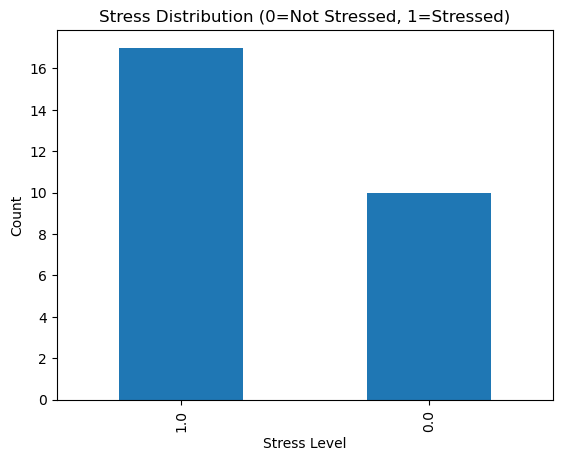

In [85]:
#______ploting-----   stressed and notstressed
plt.figure()
df['stress'].value_counts().plot(kind='bar')
plt.title("Stress Distribution (0=Not Stressed, 1=Stressed)")
plt.xlabel("Stress Level")
plt.ylabel("Count")
plt.show()